# Predicting HNLs from atmospheric D decays
This notebook does a quick estimate of HNL event rates in IceCube with D decays in the atmosphere as the source of HNLs. See the long email chain in response to the inital HNL paper for more context.

In general, the equation we're using is:

Number of HNLs produced:

$(\Phi_{\tau}(E, \cos{\theta}) +\Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X) ) \times U^2_{\tau 4} \times P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$

Number of HNLs detected:

N produced $\times (P_{\textrm{decay}} + P_{\textrm{interact}}) \times \textrm{efficiency}$


## Reviewing Carlos' initial estimate:



$N_{\textrm{HNL}} \approx (T A \Omega) ( \phi_{\nu_{\tau}} \times U^2) \times P_{\textrm{survival to detector}}\times P_{\textrm{decay in detector}}$


$N_{\nu_\mu} \approx (T A \Omega) ( \phi_{\nu_\mu}) \times P_{\textrm{int}}$


$N_{HNL} \approx (N_{\nu_\mu}) \times ( \phi_{\nu_\tau}/\phi_{\nu_\mu}) U^2 * (P_\textrm{decay in detector} \times P_\textrm{decay in detector}/P_{\textrm{int}})$

We have that, $N_{\nu_\mu} \approx 10^5$, for this analysis. In the deepcore energy range, optimistically, $\phi_{\nu_\tau}/\phi_{\nu_mu} \approx 10^{-5}$. 

We then consider two mass scales:
for $m \approx 0.1$ GeV, $c\tau\gamma \approx 10^2/U^2$ m, assuming an O(10 GeV) energy, so for an upgoing event selection search, 

$P_{\textrm{survival}} \approx \exp(-U^2\times10^4)$, while for $m \approx 1$ GeV, $c\tau\gamma \approx 10^{-2}/U^2$, so $P_{\textrm{survival}} \approx \exp(-U^2\times10^8)$; here we assume $L \approx$ O(1000km), since this is the smallest L-scale considered in our analysis. 

And $P_{\textrm{decay in detector}} = 1 - \exp(1\textrm{km}/c\tau\gamma)$, so 

$P_{\textrm{decay in detector}} = 1-\exp(-U^2\times 10)$ for 0.1 GeV and $1-\exp(-U^2 \times 10^3)$ for 1.0 GeV.
On the other hand, $P_{\textrm{int}} \approx 10^{-12}$ for this energy range. This means that
$N_{HNL_{0.1}} \approx (10^5) \times (10^{-5}) \times (\exp(-U^2\times10^4) \times (10^{12}) \times (U^2) = 10^{12} \times U^2 \times \exp(-U^2*10^4)$
for the 0.1 GeV, while for 1 GeV, we get
$N_{HNL_{1.0}} \approx 10^{12} * U^2 * \exp(-U^2*10^8)$


So for mixing $U^2 = 10^{-3}$, $N_{HNL_{1.0}}$ is 0, while $N_{HNL_{0.1}} \approx 451$

In [1]:
import numpy as np
from numpy import ma

import matplotlib.pyplot as plt
from matplotlib import cm, ticker, colors
import matplotlib.cm as cm

import pandas as pd

# from scipy import stats
# from scipy.integrate import quad
# import scipy.integrate as integrate

# import seaborn as sns

import nuflux

In [2]:
import vegas
import math
import functools

ModuleNotFoundError: No module named 'vegas'

In [8]:
from icecube.LeptonInjector import HNLDecayEnergy
FullWidth = np.vectorize( lambda x: HNLDecayEnergy.FullWidth(x) )

gamma_nu_nu_nu_overload = np.vectorize( lambda x: HNLDecayEnergy.gamma_nu_nu_nu_overload(x) )
gamma_e_e = np.vectorize( lambda x: HNLDecayEnergy.gamma_e_e(x) )
gamma_p0_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_p0_nu(x) )
gamma_nu_mu_mu = np.vectorize( lambda x: HNLDecayEnergy.gamma_nu_mu_mu(x) )
gamma_eta_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_eta_nu(x) )
gamma_rho0_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_rho0_nu(x) )
gamma_omega_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_omega_nu(x) )
gamma_etaprime_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_etaprime_nu(x) )
gamma_phi_nu = np.vectorize( lambda x: HNLDecayEnergy.gamma_phi_nu(x) )
gamma_nue_e_tau = np.vectorize( lambda x: HNLDecayEnergy.gamma_nue_e_tau(x) )
gamma_numu_mu_tau = np.vectorize( lambda x: HNLDecayEnergy.gamma_numu_mu_tau(x) )
gamma_tau_pi = np.vectorize( lambda x: HNLDecayEnergy.gamma_tau_pi(x) )
gamma_tau_K = np.vectorize( lambda x: HNLDecayEnergy.gamma_tau_K(x) )
gamma_tau_rho = np.vectorize( lambda x: HNLDecayEnergy.gamma_tau_rho(x) )

/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/jbook/i3/build/lib/icecube/LeptonInjector/__init__.py:1: UserWarning: Deprication Warning: load_pybindings() is deprecated use `from icecube._your_module import *`
  from icecube.load_pybindings import load_pybindings
/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/jbook/i3/build/lib/icecube/LeptonInjector/cascade_generator_functions.py:4: UserWarning: Using `import I3Tray` or `from I3Tray import *` is now considered depricated. Please switch to using `from icecube.icetray import I3Tray`
  from I3Tray import I3Units


## Tau neutrino flux: 

$\Phi_{\tau}(E, \cos{\theta}) + \Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X)$

In [4]:
def nutau_flux(E, cos_theta):
    '''
    Inputs:
    E, the D meson energy in GeV
    cos_theta, cosine of the zenith angle of the incoming D
    Output:
    differential flux for that energy and zenith angle
    
    We use nuflux (https://github.com/icecube/nuflux/blob/main/docs/overview.rst) 
    with H3a_SIBYLL23C_pr (https://arxiv.org/pdf/1806.04140)
    to get the prompt tau neutrino flux
    '''
    
    flux = nuflux.makeFlux('H3a_SIBYLL23C_pr')
    nu_type=nuflux.NuTau
    nu_energy=E # in GeV
    nu_cos_zenith = cos_theta
    flux_val = flux.getFlux(nu_type,nu_energy,nu_cos_zenith)
    
    return flux_val
    

In [5]:
def write_flux_dict(E_range, cos_theta_range):
    flux_dict = pd.DataFrame({"E":[], "cos_theta": [], "flux": []})
    counter = 0
    for E in E_range:
        for cos_theta in cos_theta_range:
            flux_dict.loc[counter]=([E, cos_theta, nutau_flux(E, cos_theta)])
            counter += 1
    return flux_dict

## HNL Survival Probability:
$P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$

In [6]:
R = 6357 #polar radius of earth in km
IC_depth = 1.950 #depth from surface to center of IceCube in km

#Assuming earth is a circle centered at 0,0:

def surface_to_detector(cos_theta):
    '''
    Zenith is defined at the center of the detector, so we calculate distance from the center 
    of the detector, and then subtract 0.5km
    '''
    d = IC_depth

    neg_b = -2*(R-d)*cos_theta
    sqrt_b2_minus_4ac = np.sqrt(4*(R-d)**2*cos_theta**2 + 4*(2*R*d + d**2))
    two_a = 2
    
    distance = (neg_b + sqrt_b2_minus_4ac)/two_a # (neg_b - sqrt_b2_minus_4ac)/two_a is negative
    return distance - 0.5

In [10]:
def travel_distance (cos_zenith):
    '''
    From nuflux documentation:
    "The returned flux represents the flux incident on the surface of the earth, 
    no attempt is made to include oscillations or interaction losses while traveling through the Earth."
    
    However, we see a peak in HNL parent production at around 10-20km above earth's surface. 
    Therefore, assuming HNLs are produced as soon as the parent decays we need to take this distance traveled
    into account (probablisitcally), as well as the distance from the surface to the detector.
    
    According to (https://arxiv.org/pdf/1910.12839), parent fluxes are maximal at 15.4 km above the surface, 
    and drop off above energies of 10^10 GeV.
    At 10^10GeV, the mean decay distances (in the lab frame) are of the order cm or mm, and they scale with energy. 
    This is negligible compared to the height above earth's surface at which they are produced (and indeed, 
    are beyond the resolution of our detector), so we ignore this distance.
    
    We therefore approximate HNL travel distance as 15.4 + distance travelled through the earth.
    '''

    return 15.4 + surface_to_detector(cos_zenith)

def lifetime (mHNL, U2):
    '''
    HNL rest lifetime, as a function of its mass (GeV) and mixing with the tau neutrino.
    Using decay width calculation from HNLDecayEnergy via LeptonInjector
    '''
    # Appriximation, previously used
    # return 1*(10**(-6)/U2)*(0.1/mHNL)**5 
    
    # More precise method:

    lifetime_natural_units = 1/(U2*FullWidth(mHNL)) # GeV^-1
    GeV_to_sec = 6.582e-25
    lifetime_sec = lifetime_natural_units*GeV_to_sec 
    return lifetime_sec


def survival_probability (E, cos_zenith, mHNL=0.01, U=0.001):
    '''
    The chance an HNL gets from production to the edge of the detector
    '''
    c_km = 3*10**5 #km
    c = 3*10**8
    
    travel_time = travel_distance(cos_zenith)/c_km #in the lab frame
    lorentz_gamma = E/mHNL #E/(mHNL*c)
    
    exponent = -travel_time/(lorentz_gamma*lifetime(mHNL, U))

    if (np.exp(exponent) > 0).any:
        return np.exp(exponent)
    return 1 + exponent
    
def cross_sectional_area():
    '''
    Gives the cross sectional area relevant to our flux and decay calculations
    Written as a function so we can input a more precise calculation in the future if desired
    '''
    area = 10**10 # 1 km^2 in units of cm^2
    return area

In [11]:

def lifetime_old (mHNL, U2):
    '''
    HNL rest lifetime, as a function of its mass (GeV) and mixing with the tau neutrino.
    Using decay width calculation from HNLDecayEnergy via LeptonInjector
    '''
    # Approximation, previously used
    return 1*(10**(-6)/U2)*(0.1/mHNL)**5 



In [12]:
n_points=100
m_range = np.logspace(-2, 0.3, n_points)
U_range = np.logspace(-6.5, 0, n_points)

X, Y = np.meshgrid(m_range, U_range, indexing='ij')

z = lifetime_old(X, Y)
z_new = lifetime(X, Y)

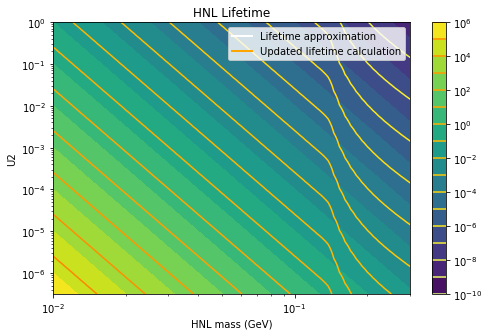

In [39]:
fig, ax = plt.subplots()
fig.set_size_inches(8, 5)

lev_exp = np.arange(-10., 7)
levs = np.power(10, lev_exp)

cs1 = ax.contourf(X, Y, z_new, levs, norm=colors.LogNorm())
# cbar = fig.colorbar(cs1)

CS1 = ax.contour(cs1, levels=levs, cmap='Wistia', norm=colors.LogNorm(min(levs), max(levs)))


cs = ax.contourf(X, Y, z, levs, norm=colors.LogNorm())
cbar = fig.colorbar(cs)
cbar.add_lines(CS1)
# CS = ax.contour(cs, levels=[10, 100, 1000], colors='orange')
# cbar.add_lines(CS)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel("U2")
ax.set_xlim(0.01, 0.3)
ax.set_ylim(10**(-6.5), 1)

plt.title("HNL Lifetime")
# Create proxy artists for legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='white', lw=2, label='Lifetime approximation'),
    Line2D([0], [0], color='orange', lw=2, label='Updated lifetime calculation'),
]

# Add legend
ax.legend(handles=legend_elements, loc='best')

plt.show()

## Number of HNLs reaching the detector:

$(\Phi_{\tau}(E, \cos{\theta}) +\Phi_D(E, \cos{\theta})\times \Gamma(D \rightarrow \tau + X) ) \times U^2_{\tau 4} \times P_{\textrm{survival}}(L(\theta), E, \tau(m_{\textrm{HNL}}, U^2_{\tau4}))$


## Interaction Probability:
$e^{-NC \times U^2_{\tau 4} \times cd}$

The neutral current cross section for tau neutrinos is (as far as I can tell, which isn't very far)about order 10^-39 cm^2. We must surpress this by a reasonable $U_{\tau 4}^2$ or order $10^{-3}$ at largest (more likely below $10^{-5}$. The maximum column depth a neutrino will pass through is (pulled from Alex Wen's slides from a few months back) 10^10 g/cm^2
Multplying the cross section, column depth, and mixing we get an exponent of order 10^-42 or smaller. (I'm not sure what to do with the gram unit, but even if we take the number of protons in a gram, the 10^26 factor won't make this statistically significant).

We don't have enough incoming neutrinos in the world for this to be relevant.

## Decay Probability:

In [18]:
def decay_probability (E, mHNL=0.01, U=0.001):
    '''
    The chance an HNL decays at some point in the detector
    1 - chance HNL travels all the way through the detector
    '''
    c_km = 3*10**5 #km
    c = 3*10**8
    
    travel_time = 1/c_km #in the lab frame
    lorentz_gamma = E/mHNL # E/(mHNL*c)
    survival_prob = np.exp(-travel_time/(lorentz_gamma*lifetime(mHNL, U)))
    return 1-survival_prob

# Detection probability

In [19]:
# Detector Efficiency: For now, we'll leave this at one and adjust later.
detector_efficiency=1

## Calculate visible decay modes

In [21]:
def fraction_visible(mHNL):
    '''
    Calculates the fractions of decays at this mass which produce ANY visible energy
    This does NOT account for the likelihood of seeing an event given a specific detector energy threshhold
    '''
    if type(mHNL)== int:
        mHNL = float(mHNL)
    full_decay_width = FullWidth(mHNL)
    decay_00 = gamma_nu_nu_nu_overload(mHNL) # decays to 3 neutrinos produce no visible energy
    return 1-(decay_00/full_decay_width)


In [22]:
def fraction_in_nicks_estimate(mHNL):
    '''
    For comparison with Nick's estimate of specifically HNL -> e+e-
    '''
    if type(mHNL) == int:
        mHNL=float(mHNL)
    full_decay_width = FullWidth(mHNL)
    decay_01 = gamma_e_e(mHNL)
    
    return decay_01/full_decay_width

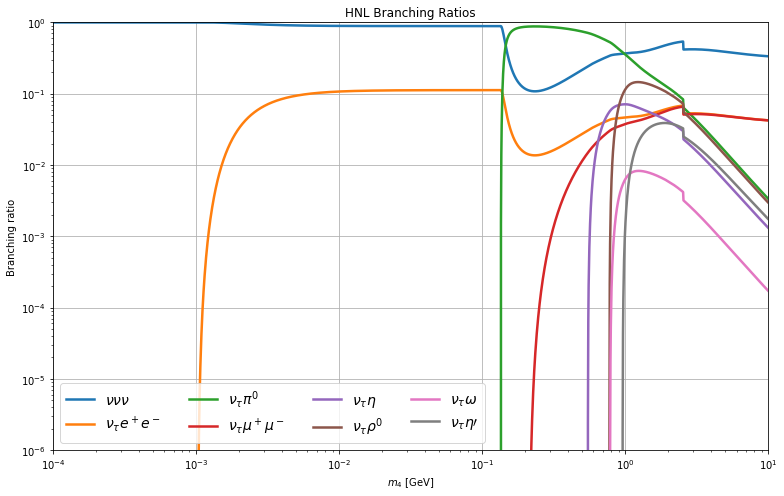

In [23]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive']
decay_channels = [r'$\nu\nu\nu$', r'$\nu_\tau e^+e^-$', r'$\nu_\tau\pi^0$', r'$\nu_\tau \mu^+\mu^-$',
                   r'$\nu_\tau\eta$', r'$\nu_\tau\rho^0$', r'$\nu_\tau\omega$', r'$\nu_\tau\eta\prime$']


hnl_mass =  np.logspace(-4, 1, 2000) #np.linspace(0.05, 1.05, 2000)
    
full_decay_width = FullWidth(hnl_mass)

decay_00 = gamma_nu_nu_nu_overload(hnl_mass)
decay_01 = gamma_e_e(hnl_mass)
decay_02 = gamma_p0_nu(hnl_mass)
decay_03 = gamma_nu_mu_mu(hnl_mass)
decay_04 = gamma_eta_nu(hnl_mass)
decay_05 = gamma_rho0_nu(hnl_mass)
decay_06 = gamma_omega_nu(hnl_mass)
decay_07 = gamma_etaprime_nu(hnl_mass)
decay_08 = gamma_phi_nu(hnl_mass)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11,7))

lw_sub = 2.5

# plot branching ratios
ax.plot(hnl_mass, decay_00/full_decay_width, lw=lw_sub, label=r'$\nu\nu\nu$')
ax.plot(hnl_mass, decay_01/full_decay_width, lw=lw_sub, label=r'$\nu_\tau e^+e^-$')
ax.plot(hnl_mass, decay_02/full_decay_width, lw=lw_sub, label=r'$\nu_\tau\pi^0$')
ax.plot(hnl_mass, decay_03/full_decay_width, lw=lw_sub, label=r'$\nu_\tau \mu^+\mu^-$')
ax.plot(hnl_mass, decay_04/full_decay_width, lw=lw_sub, label=r'$\nu_\tau\eta$')
ax.plot(hnl_mass, decay_05/full_decay_width, lw=lw_sub, label=r'$\nu_\tau\rho^0$')
ax.plot(hnl_mass, decay_06/full_decay_width, lw=lw_sub, label=r'$\nu_\tau\omega$')
ax.plot(hnl_mass, decay_07/full_decay_width, lw=lw_sub, label=r'$\nu_\tau\eta\prime$')

ax.set_title('HNL Branching Ratios')
ax.set_ylabel(r'Branching ratio')

#     pilars paper
ax.set_ylim(1e-6, 1e-00)
ax.set_xlim(1e-4, 10)
ax.set_xlabel(r'$m_4$ [GeV]')

ax.set_xscale('log')
ax.set_yscale('log')

plt.grid(True, which="major", axis='both')

ax.legend(
    fontsize=14,
    loc='lower left',
    ncol=4,
)

fig.tight_layout()

### Do the integral with vegas

In [22]:
def total_events_detected(m, U, integration_vars):
    seconds = 10*365*24*60*60 # seconds in ten years of live time
    cos_zenith, logE  = integration_vars
    
    E = 10**logE
    jacobian = E*np.log(10) # np.log gives natural logarithm
    consts = 2*np.pi*seconds
    
    A = cross_sectional_area()
    hnl_flux = nutau_flux(E, cos_zenith)*U
    
    survival_prob = survival_probability (E, cos_zenith, m, U)
    decay_prob = decay_probability(E, m, U)
    
    return hnl_flux*survival_prob*consts*decay_prob*A*jacobian


In [23]:
cos_z_range = [-1, 1]
E_range = [1, 6]

part_func1 = functools.partial(total_events_detected, 0.01, 0.001)
# integ = vegas.Integrator([cos_z_range, E_range])

# result = integ(part_func1, nitn=10, neval=10000)
# print(result.summary())
# print('result = %s    Q = %.2f' % (result, result.Q))

NameError: name 'functools' is not defined

In [24]:
cos_z_range = [-1, 1]
E_range = [1, 6]
m_range = np.logspace(-6 ,-1,10)
U_range = np.logspace(-6, -3, 10)

integ = vegas.Integrator([cos_z_range, E_range])
events_detected = pd.DataFrame({"m":[], "U":[], "num_events":[]})
   
for i, mass in enumerate(m_range):
    print(i)
    for mixing in U_range:
        part_func = functools.partial(total_events_detected, mass, mixing)      
        result = integ(part_func, nitn=10, neval=1000)
        events_detected = pd.concat([pd.DataFrame([[mass, mixing, result.mean]], columns=events_detected.columns), events_detected], ignore_index=True)

0
1
2
3
4
5
6
7
8
9


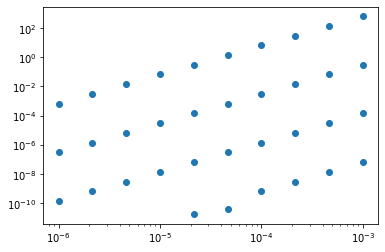

In [57]:
plt.scatter(events_detected['U'], events_detected['num_events'])
plt.xscale('log')
plt.yscale('log')

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: Log scale: values of z <= 0 have been masked
  if __name__ == '__main__':


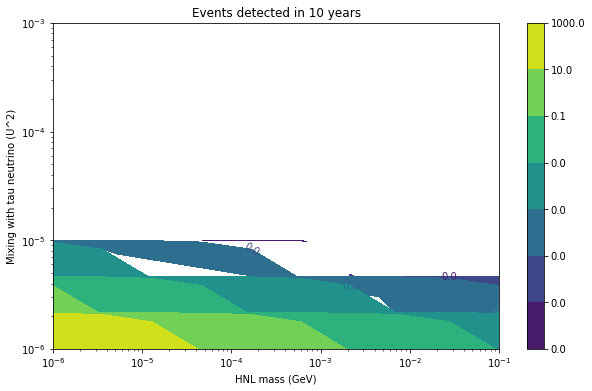

In [62]:
from numpy import ma
import matplotlib
#Isoparticle contour for detected HNLs
X, Y = np.meshgrid(m_range, U_range)
n_events = np.array_split(events_detected["num_events"], len(m_range))

fig, ax = plt.subplots(figsize=(10, 6))

CS = ax.contourf(X,Y,n_events, norm=matplotlib.colors.LogNorm())

# CS.yscale('log')
ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Events detected in 10 years')
ax.set_xlabel("HNL mass (GeV)")
ax.set_ylabel("Mixing with tau neutrino (U^2)")
ax.set_xscale ("log")
ax.set_yscale("log")
# ax.set_xlim(10**(-6), 10**(-5))
# ax.set_ylim(10**(-6), 10**(-5))
cbar = fig.colorbar(CS)

In [26]:
m_range = np.logspace(-6 ,-1,10)
U_range = np.logspace(-6, -3, 10)
# z = np.log(np.array(integration_results['num_detected']))
z = np.array(integration_results['num_detected'])
M, U = np.meshgrid(m_range, U_range)
Z = z.reshape((10, -1))

# plt.contourf(M, U, Z)
# # plt.legend()
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('mHNL')
# plt.ylabel('U^2')

# # Make a colorbar for the ContourSet returned by the contourf call.
# cbar = plt.colorbar()
# cbar.ax.set_ylabel('log(Events predicted in 10 years)')
# # cbar.ax.set_yscale('log')
# # Add the contour line levels to the colorbar
# # cbar.add_lines(CS2)
# plt.show()

NameError: name 'integration_results' is not defined

(1e-06, 1e-05)

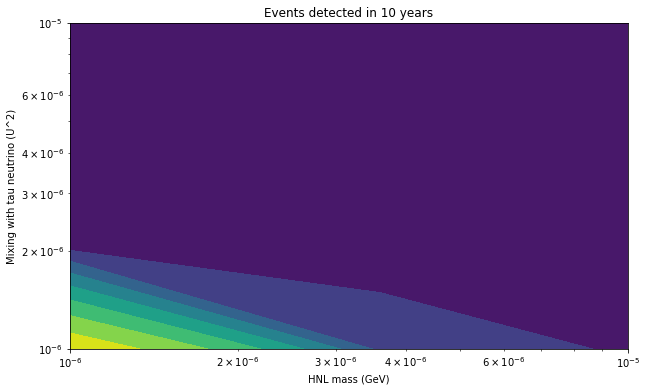

In [38]:
#Isoparticle contour for detected HNLs
X, Y = np.meshgrid(m_range, U_range)
n_events = np.array_split(events_detected["num_events"], len(m_range))

fig, ax = plt.subplots(figsize=(10, 6))
CS = ax.contourf(X,Y,n_events)
# CS.yscale('log')
# ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Events detected in 10 years')
ax.set_xlabel("HNL mass (GeV)")
ax.set_ylabel("Mixing with tau neutrino (U^2)")
ax.set_xscale ("log")
ax.set_yscale("log")
ax.set_xlim(10**(-6), 10**(-5))
ax.set_ylim(10**(-6), 10**(-5))


## Plots from longer integral run


In [23]:
integration_results = pd.read_csv("predicted_events_compare_w_nick.csv") #pd.read_csv("predicted_events4.csv")
more_results = pd.read_csv("predicted_events4more.csv")
fullresults= pd.read_csv("predicted_events_newrange.csv")

In [77]:
nicks_results = pd.read_csv('/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/nkamp/IceCube/PromptHNL/ForJulia.txt', delimiter=' ')
nicks_results.columns=['m','U', 'num_1year']

In [175]:
integration_results['visible_nevents'] = integration_results['num_detected']*fraction_visible(integration_results['m'])

integration_results['e+e- events'] = integration_results['num_detected']*fraction_in_nicks_estimate(integration_results['m'])

integration_results.to_csv("results_with_branching.csv", index=False)

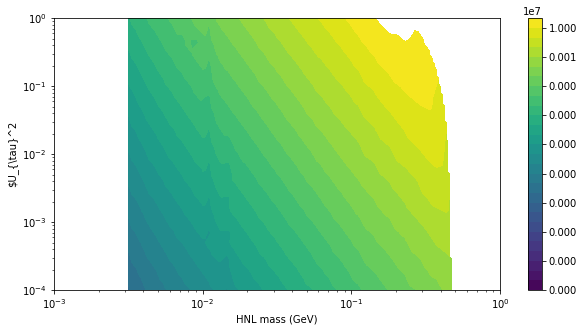

In [99]:
# Load Nick's estimate
m_nick= nicks_results['m']
u_nick = nicks_results['U']

nicks_masses = sorted(set(m_nick))
nicks_masses.pop() # Removing the mass with only 99 values do it's all square - they're all Nan anyway

m_nick = np.asarray(nicks_masses)
u_nick = np.asarray(sorted(set(u_nick)))

Xn, Yn, = np.meshgrid(m_nick, u_nick, indexing='ij')

zn = np.asarray(nicks_results['num_1year']*10)
zn = zn[-19900:] #Remove z values associated with removed mass
zn = zn.reshape(199, -1)

plt.rcParams['figure.figsize'] = [10, 5]
fig1, ax1 = plt.subplots()

lev_exp = np.arange(-20., 9)
levs = np.power(10, lev_exp)
nicks = ax1.contourf(Xn, Yn, zn, levs, norm=colors.LogNorm())

cbar = fig1.colorbar(nicks)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('HNL mass (GeV)')
ax1.set_ylabel(r"$U_{\tau}^2")
ax1.set_xlim(0.001, 1)
ax1.set_ylim(10**(-4), 1)
plt.show()

In [125]:
#Now plot my estimates

N = 100
# m_range = np.logspace(-6 ,1, N)
# U_range = np.logspace(-9, -3, N)

m_range = np.logspace(-3, 0, 100)
U_range = np.logspace(-4, -1, 100)

X, Y = np.meshgrid(m_range, U_range, indexing='ij')

z = np.asarray(integration_results["num_detected"])
z = z.reshape((100, -1))

nick_compare = np.asarray(integration_results['e+e- events'])
nick_compare = nick_compare.reshape((100, -1))

visible_events = np.asarray(integration_results['visible_nevents'])
visible_events = visible_events.reshape((100, -1))
# z = ma.masked_where(z <= 0, z)

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:8: UserWarning: Log scale: values of z <= 0 have been masked
  


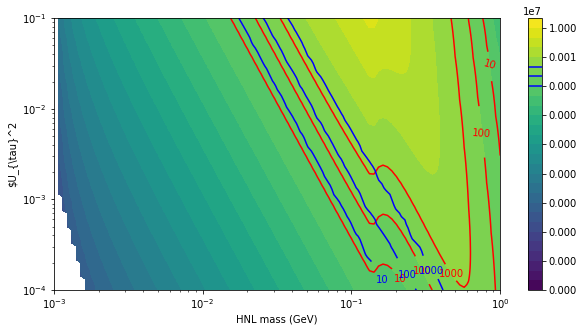

Text(0.5, 0.98, 'HNL -> e+e- in 10 years')

In [159]:
# Automatic selection of levels works; setting the
# log locator tells contourf to use a log scale:
plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()

lev_exp = np.arange(-20., 9)
levs = np.power(10, lev_exp)
cs = ax.contourf(X, Y, nick_compare, levs, norm=colors.LogNorm())
# cs = ax.contourf(X, Y, z, levs, norm=colors.LogNorm())

cbar = fig.colorbar(cs)

CS2 = plt.contour(cs, levels=[10, 100, 1000], colors='r')
cbar.add_lines(CS2)

CS_Nick = plt.contour(nicks, levels=[10, 100, 1000], colors = 'b')
cbar.add_lines(CS_Nick)


ax.clabel(CS2, inline=True, fontsize=10)
ax.clabel(CS_Nick, inline=True, fontsize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
ax.set_xlim(0.001, 1)
ax.set_ylim(1e-4, 1e-1)
plt.show()
fig.suptitle("HNL -> e+e- in 10 years")
# plt.legend()

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:7: UserWarning: Log scale: values of z <= 0 have been masked
  import sys


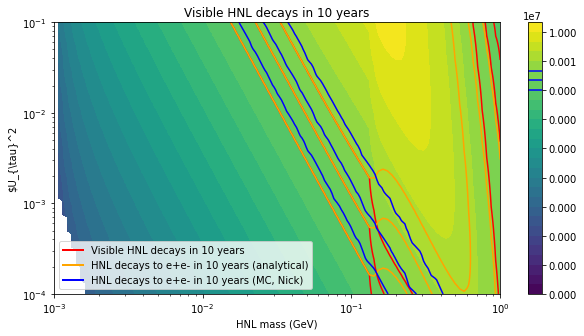

In [174]:
plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()

lev_exp = np.arange(-20., 9)
levs = np.power(10, lev_exp)

cs1 = ax.contourf(X, Y, visible_events, levs, norm=colors.LogNorm())
cbar = fig.colorbar(cs1)

CS2 = ax.contour(cs1, levels=[10, 100, 1000], colors='r')
cbar.add_lines(CS2)

# ax.clabel(CS2, inline=1., fontsize=10)

CS_ee = ax.contour(cs, levels=[10, 100, 1000], colors='orange')
cbar.add_lines(CS_ee)

CS_Nick = ax.contour(nicks, levels=[10, 100, 1000], colors='b')
cbar.add_lines(CS_Nick)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
ax.set_xlim(0.001, 1)
ax.set_ylim(1e-4, 1e-1)

plt.title("Visible HNL decays in 10 years")
# Create proxy artists for legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='Visible HNL decays in 10 years'),
    Line2D([0], [0], color='orange', lw=2, label='HNL decays to e+e- in 10 years (analytical)'),
    Line2D([0], [0], color='b', lw=2, label='HNL decays to e+e- in 10 years (MC, Nick)')
]

# Add legend
ax.legend(handles=legend_elements, loc='lower left')

plt.show()

In [158]:
print(X.shape, Y.shape, visible_events.shape)
print(np.min(X), np.max(X))
print(np.min(Y), np.max(Y))
print(np.min(visible_events), np.max(visible_events))

(100, 100) (100, 100) (100, 100)
0.001 1.0
0.0001 0.1
0.0 25069074.330799293


## Old Things saved for posterity

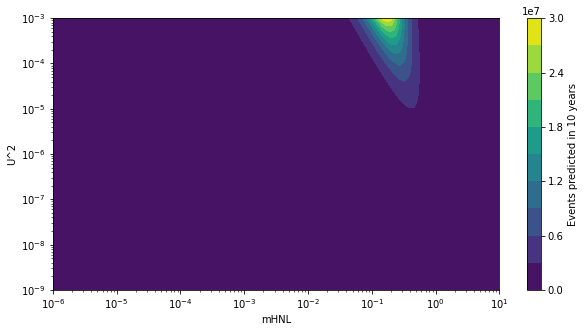

In [76]:
#Pretty plotting version

plt.rcParams['figure.figsize'] = [10, 5]

m_range = np.logspace(-6 ,1,100)
U_range = np.logspace(-9, -3, 100)

z = np.array(integration_results['num_detected'])
M, U = np.meshgrid(m_range, U_range, indexing='ij')
Z = z.reshape((100, -1))

plt.contourf(M, U, Z, 10)
# plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('mHNL')
plt.ylabel('U^2')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = plt.colorbar()
cbar.ax.set_ylabel('Events predicted in 10 years')
# cbar.ax.set_yscale('log')
# Add the contour line levels to the colorbar

# CS2 = plt.contour(CS, levels=CS.levels[::2], colors='r')
# cbar.add_lines(CS2)
plt.show()

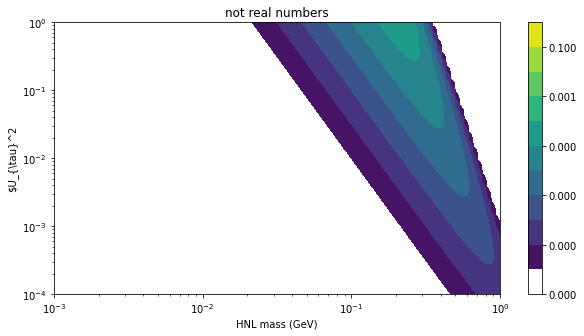

In [48]:
# Sanity check:
# Let's approximate ot find our expected U, m, dependence:

def approximate(m, U):
    A = 10000
    B = 1
    
    return U*np.exp(-A*U*m**6)*(1-np.exp(-B*U*m**6))

N = 100
m_range = np.logspace(-3 ,0., N)
U_range = np.logspace(-4, 0., N)
X, Y = np.meshgrid(m_range, U_range)

z = approximate(X, Y)


z = ma.masked_where(z <= 0, z)
plt.rcParams['figure.figsize'] = [10, 5]
fig, ax = plt.subplots()
# lev_exp = np.arange(np.floor(np.log10(z.min())-1),
#                    np.ceil(np.log10(z.max())+1))
lev_exp = np.arange(-323., 0.)
custom_levs=[-325, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0.]
levs = np.power(10, custom_levs)
cs = ax.contourf(X, Y, z, levs, norm=colors.LogNorm())
# cs1 = ax.contourf(X1, Y1, z1, levs, norm=colors.LogNorm())

cbar = fig.colorbar(cs)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('HNL mass (GeV)')
ax.set_ylabel(r"$U_{\tau}^2")
ax.set_title("not real numbers")
plt.show()

### Integral for total events occuring, not just decaying in the detector

In [17]:
import functools
m = 0.001
U = 0.00001

def total_events_predicted(m, U, integration_vars):
    '''
    Events predicted to reach the detector in 10 years
    '''
    seconds = 10*365*24*60*60 # seconds in ten years of live time
    cos_zenith, logE  = integration_vars
    E = 10**logE
    consts = 2*np.pi*seconds #Ie, not zenith dependent   
    A = cross_sectional_area()
    
    hnl_flux = U*nutau_flux(E, cos_zenith)
    
    survival_prob = survival_probability (E, cos_zenith, m, U)
    jacobian = E*np.log(10)
    
    return hnl_flux*survival_prob*consts*A*jacobian

part_func = functools.partial(total_events_predicted, m, U)


In [18]:
cos_z_range = [-1, 1]
E_range = [1, 6]

part_func = functools.partial(total_events_predicted, 0.01, 0.001)
integ = vegas.Integrator([cos_z_range, E_range])

result = integ(part_func, nitn=10, neval=10000)
print(result.summary())
print('result = %s    Q = %.2f' % (result, result.Q))

itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   4.2695(58)e+07  4.2695(58)e+07      0.00     1.00
  2   4.2767(31)e+07  4.2750(27)e+07      1.20     0.27
  3   4.2825(24)e+07  4.2793(18)e+07      2.69     0.07
  4   4.2758(19)e+07  4.2777(13)e+07      2.35     0.07
  5   4.2789(18)e+07  4.2781(11)e+07      1.84     0.12
  6   4.2791(15)e+07  4.27844(86)e+07     1.53     0.18
  7   4.2793(14)e+07  4.27868(73)e+07     1.32     0.24
  8   4.2807(13)e+07  4.27917(64)e+07     1.40     0.20
  9   4.2803(12)e+07  4.27940(57)e+07     1.31     0.23
 10   4.2810(12)e+07  4.27971(51)e+07     1.34     0.21

result = 4.27971(51)e+07    Q = 0.21


In [48]:
cos_z_range = [-1, 1]
E_range = [1, 6]
m_range = np.logspace(-6 ,-3,10)
U_range = np.logspace(-6, -3, 10)

integ = vegas.Integrator([cos_z_range, E_range])
events_predicted = pd.DataFrame({"m":[], "U":[], "num_incident":[]})
for i, mass in enumerate(m_range):
    print(i)
    for mixing in U_range:
        part_func = functools.partial(total_events_predicted, mass, mixing)      
        result = integ(part_func, nitn=10, neval=1000)
        events_predicted = pd.concat([pd.DataFrame([[mass, mixing, result.mean]], columns=events_predicted.columns), events_predicted], ignore_index=True)

0
1
2
3
4
5
6
7
8
9
